In [46]:
import wandb
import pandas as pd
import os
import json
import math

import seaborn as sns
import matplotlib.pyplot as plt
from plots.utils import load_runs_from_wandb

plt.rcParams['text.usetex'] = False


In [47]:
# run_names = [
#     # LinearGater Runs:
#     "18M_2025.08.31_09.35",
#     "32M_2025.08.31_12.06",
#     # "73M_2025.08.24_09.01",
#     "73M_2025.08.31_05.11",
#     "130M_2025.08.24_09.01",
#     # RandomGater Runs:
#     "j2tkor55",
#     "xjdm3gvb",
#     "73M_2025.08.30_08.19",
#     "130M_2025.08.30_08.19",
#     # Nawrot Runs:
#     "18M_2025.09.03_05.39",
#     "32M_2025.09.03_05.39",
#     "73M_2025.09.04_08.54",
#     "130M_2025.09.03_05.34",
#     # SequentialDependentLinearGater Runs:
#     "18M_2025.09.17_07.52",
#     "32M_2025.09.17_07.52",
#     "73M_2025.09.17_07.52",
#     "130M_2025.09.20_07.07",
#     # ScaledSequentialyDependentLinearGater Runs:
#     "18M_2025.09.29_03.44",
#     "32M_2025.09.28_23.19",
#     "73M_2025.10.06_08.08",
#     "130M_2025.10.05_02.16",
#     # Flexify Runs:
#     # "32M_2025.10.12_00.54",
#     # "73M_2025.10.12_22.42",
#     # Non-deviation runs:
#     "18M_2025.10.28_19.02",
#     "32M_2025.10.28_19.02",
#     "73M_2025.10.27_05.53",
#     "130M_2025.10.31_06.36"
# ]

run_names = [
    "147M_random___2025.11.19_22.45",
    "147M_nawrot___2025.11.19_15.28",
    "147M_sequential___2025.11.19_03.51"
]

In [48]:
df, configs = load_runs_from_wandb(run_names)

In [49]:
print("hours to train:")
df.groupby(["GaterClass", "model_size"])["batch_wallclock_time"].sum() / (60*60)

hours to train:


GaterClass                             model_size
ExactRandomGater                       147M           6.011155
NawrotGater                            147M           7.160357
ScaledSequentialyDependentLinearGater  147M          11.407320
Name: batch_wallclock_time, dtype: float64

In [50]:
for config in configs:
    if 'consistency_loss_weight' in config:
        consistency_loss_weight = config['consistency_loss_weight']
    else:
        consistency_loss_weight=2.
    
    if 'relative_gating_loss_weight' in config:
        relative_gating_loss_weight = config['relative_gating_loss_weight']
    else:
        relative_gating_loss_weight = 1.
    
    print(f"{config['model_size']} {config['GaterClass']} {consistency_loss_weight=} {relative_gating_loss_weight=}")

147M ExactRandomGater consistency_loss_weight=2.0 relative_gating_loss_weight=1.0
147M NawrotGater consistency_loss_weight=2.0 relative_gating_loss_weight=0
147M ScaledSequentialyDependentLinearGater consistency_loss_weight=0.01 relative_gating_loss_weight=0.01


In [51]:
config

{'seed': 42,
 'num_heads': 12,
 'GaterClass': 'ScaledSequentialyDependentLinearGater',
 'batch_size': 8,
 'model_size': '147M',
 'num_epochs': 1,
 'vocab_size': 320,
 'bytes_limit': 6000000000,
 'n_up_layers': 4,
 'aspect_ratio': None,
 'gater_kwargs': {'filter_size': 8, 'scale_factor': 0.0625},
 'learn_gating': True,
 'n_mid_layers': 12,
 'warmup_bytes': 450000000,
 'discount_rate': 0.99,
 'embedding_dim': 768,
 'learning_rate': 0.0015,
 'n_down_layers': 4,
 'updownsampler': 'sequential',
 'UpsamplerClass': 'clean_code.modules.DistributeAddUpsampler',
 'max_seq_length': 4096,
 'sliding_window': 64,
 'stop_condition': 'BytesLimitCondition',
 'training_bytes': 6000000000,
 'validate_every': 100,
 'downsample_rate': 0.2,
 'DownSamplerClass': 'SelectTokenDownsampler',
 'lr_total_updates': 45776.3671875,
 'step_print_every': 10,
 'warm_start_steps': None,
 'lr_warmup_updates': 3433.2275390625,
 'resume_checkpoint': None,
 'effective_batch_size': 128,
 'downsample_rate_target': 0.2,
 'consi

In [58]:

df["val_loss_bpb"] = df["val_late_ar_loss"] * math.log2(math.e)
df["loss_bpb"] = df["late_ar_loss"] * math.log2(math.e)



val_steps = df["val_true_downsample_rate"].notna()

df_val = df[
    val_steps
]

df_val.head()

,val_ar_loss,non_padding_bytes_elapsed,learning_rate,mean_selected_action_ce,_runtime,true_downsample_rate,downsample_rate_target,val_mean_selected_action_ce,_timestamp,early_ar_loss,...,rate_consistency_loss,val_true_downsample_rate,val_rate_consistency_loss,run_name,model_size,GaterClass,UpsamplerClass,seed,val_loss_bpb,loss_bpb
0,14.039765,131072.0,0.000150,0.5,8.842636,0.200195,0.2,0.5,1.763589e+09,7.244201,...,-0.000523,0.200195,-0.000523,147M_random___2025.11.19_22.45,147M,ExactRandomGater,clean_code.modules.DistributeAddUpsampler,42,20.255100,20.323553
400,5.798488,52559872.0,0.000307,0.5,205.611629,0.200195,0.2,0.5,1.763589e+09,6.301488,...,-0.000523,0.200195,-0.000523,147M_random___2025.11.19_22.45,147M,ExactRandomGater,clean_code.modules.DistributeAddUpsampler,42,8.365450,8.370590
800,3.499220,104988672.0,0.000465,0.5,396.127008,0.200195,0.2,0.5,1.763589e+09,5.965376,...,-0.000523,0.200195,-0.000523,147M_random___2025.11.19_22.45,147M,ExactRandomGater,clean_code.modules.DistributeAddUpsampler,42,5.048307,5.084116
1200,2.372698,157417472.0,0.000622,0.5,587.596520,0.200195,0.2,0.5,1.763589e+09,5.286169,...,-0.000523,0.200195,-0.000523,147M_random___2025.11.19_22.45,147M,ExactRandomGater,clean_code.modules.DistributeAddUpsampler,42,3.423080,3.415833
1600,2.095114,209846272.0,0.000779,0.5,779.600146,0.200195,0.2,0.5,1.763590e+09,4.877391,...,-0.000523,0.200195,-0.000523,147M_random___2025.11.19_22.45,147M,ExactRandomGater,clean_code.modules.DistributeAddUpsampler,42,3.022610,3.052113


In [59]:
df_val.keys()

Index(['val_ar_loss', 'non_padding_bytes_elapsed', 'learning_rate',
       'mean_selected_action_ce', '_runtime', 'true_downsample_rate',
       'downsample_rate_target', 'val_mean_selected_action_ce', '_timestamp',
       'early_ar_loss', 'flops', 'flops_elapsed', 'in_context_learning_score',
       'batch_wallclock_time', 'model_flops_utilization', 'val_gating_loss',
       'gating_loss', 'pre_clip_grad_norm', 'all_bytes_elapsed',
       'non_padding_bytes', 'val_in_context_learning_score',
       'val_early_ar_loss', 'total_loss', 'val_downsample_rate_target',
       'val_total_loss', 'all_bytes', 'late_ar_loss', '_step', 'ar_loss',
       'val_late_ar_loss', 'rate_consistency_loss', 'val_true_downsample_rate',
       'val_rate_consistency_loss', 'run_name', 'model_size', 'GaterClass',
       'UpsamplerClass', 'seed', 'val_loss_bpb', 'loss_bpb'],
      dtype='object')

In [ ]:
# df_val_of_interest = df_val[df_val["GaterClass"] == "ScaledSequentialyDependentLinearGater"]

sizes = {
    "18M": 0.8,
    "32M": 1.,
    "73M": 1.2,
    "130M": 1.5
}

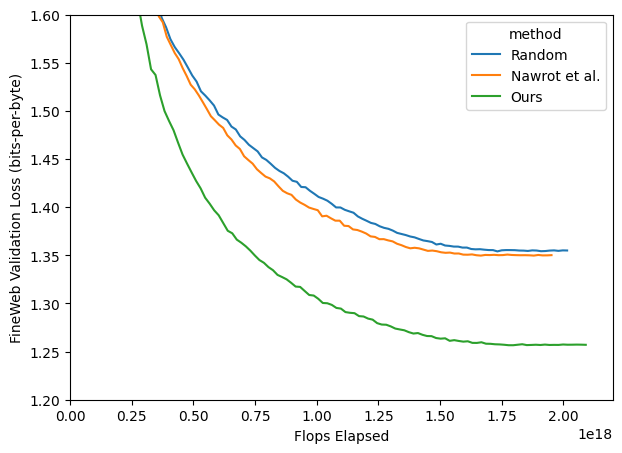

In [65]:
plt.figure(figsize=(7, 5))

name_to_label = {
    "147M_random___2025.11.19_22.45": "Random",
    "147M_nawrot___2025.11.19_15.28": "Nawrot et al.",
    "147M_sequential___2025.11.19_03.51": "Ours"
}

df_val_plot = df_val.copy()
df_val_plot["method"] = df_val_plot["run_name"].map(name_to_label)

sns.lineplot(
    data=df_val_plot,
    x="flops_elapsed",
    y="val_loss_bpb",
    hue="method",
)

plt.xlabel("Flops Elapsed")
plt.ylabel("FineWeb Validation Loss (bits-per-byte)")

plt.ylim(1.2, 1.6)
plt.xlim(0, 2.2e18)

plt.show()

<Axes: xlabel='all_bytes_elapsed', ylabel='mean_selected_action_ce'>

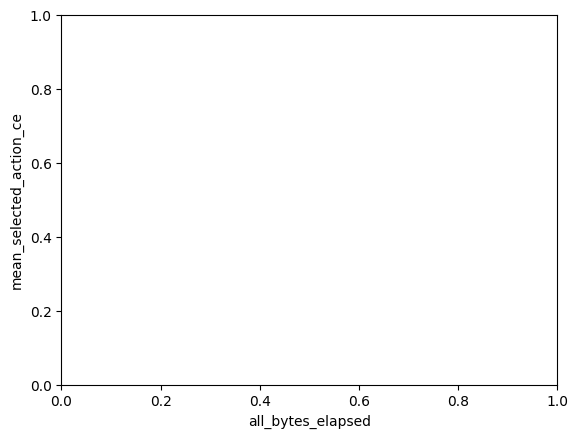

In [55]:


sns.lineplot(
    data=df_val[df_val["model_size"] == "130M"],
    x="all_bytes_elapsed",
    y="mean_selected_action_ce",
    hue="GaterClass",
)